Import packages

In [ ]:
!pip install -q 'qiskit[visualization]' qiskit-ibm-runtime qiskit-aer
from qiskit import QuantumCircuit
from qiskit.visualization import plot_histogram
from qiskit.transpiler.preset_passmanagers import generate_preset_pass_manager
from qiskit.quantum_info import SparsePauliOp
from qiskit_ibm_runtime import (
    SamplerV2 as Sampler,
    EstimatorV2 as Estimator,
    QiskitRuntimeService,
)

### Experiment 1: Bell State

Design circuit

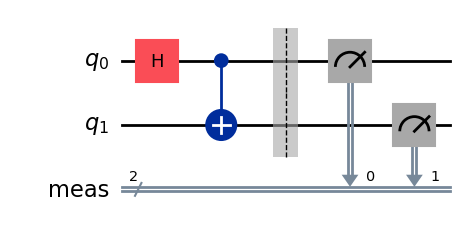

In [ ]:
bell = QuantumCircuit(2)
bell.h(0)
bell.cx(0, 1)
bell.measure_all()
bell.draw("mpl")

Run experiment

qiskit_runtime_service.__init__:WARNING:2026-04-25 15:30:37,688: Instance was not set at service instantiation. Free and trial plan instances will be prioritized. Based on the following filters: (tags: None, region: us-east, eu-de), and available plans: (open), the available account instances are: open-instance. If you need a specific instance set it explicitly either by using a saved account with a saved default instance or passing it in directly to QiskitRuntimeService().
qiskit_runtime_service.__init__:WARNING:2026-04-25 15:30:39,855: Instance was not set at service instantiation. Free and trial plan instances will be prioritized. Based on the following filters: (tags: None, region: us-east, eu-de), and available plans: (open), the available account instances are: open-instance. If you need a specific instance set it explicitly either by using a saved account with a saved default instance or passing it in directly to QiskitRuntimeService().
qiskit_runtime_service.backends:WARNING:20

ibm_fez


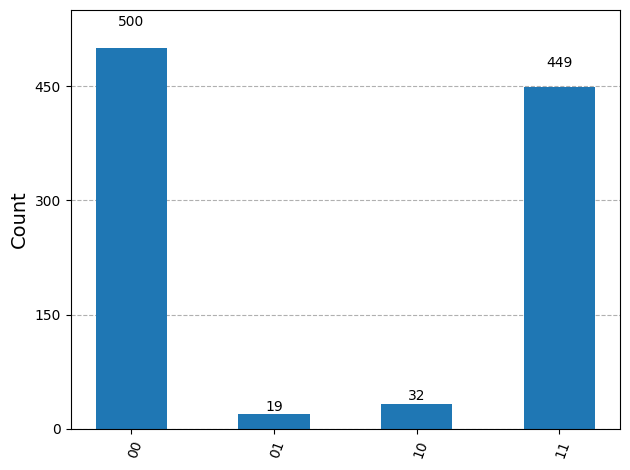

In [ ]:
def run_circuit_and_get_counts(circuit, backend, shots=1000):
    """
    Runs a quantum circuit on a specified backend and returns the measurement counts.

    Args:
        circuit (QuantumCircuit): The quantum circuit to run.
        backend: The Qiskit backend.
        shots (int): The number of shots to run the circuit.

    Returns:
        dict: A dictionary of measurement counts.
    """
    pm = generate_preset_pass_manager(backend=backend, optimization_level=1)
    isa_circuit = pm.run(circuit)

    sampler = Sampler(mode=backend)

    job = sampler.run([isa_circuit], shots=shots)
    result = job.result()

    return result[0].data.meas.get_counts()

QiskitRuntimeService.save_account(
    channel="ibm_quantum_platform",
    token="<YOUR_IBM_QUANTUM_API_TOKEN>",
    overwrite=True,
    set_as_default=True,
)

service = QiskitRuntimeService()

backend = service.least_busy(operational=True, simulator=False, min_num_qubits=127)

print(backend.name)

counts = run_circuit_and_get_counts(bell, backend, shots=1000)
plot_histogram(counts)

### Experiment 2: Two-Qubit Transverse-Field Ising Model

Design circuit

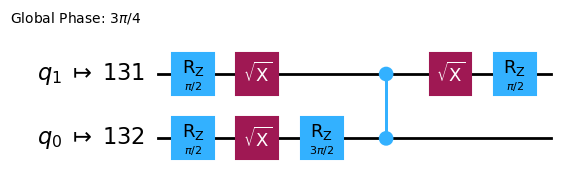

In [ ]:
J = 1.0
hx = -0.5
obs = SparsePauliOp.from_list(
    [("ZZ", J),
     ("XI", hx),
      ("IX", hx)])
qc = QuantumCircuit(2)
qc.h(0)
qc.cx(0, 1)
qc.x(1)
qc.z(0)
target = backend.target
pm = generate_preset_pass_manager(target=target, optimization_level=3)
qc_isa = pm.run(qc)
obs_isa = obs.apply_layout(layout=qc_isa.layout)
qc_isa.draw("mpl")

Run experiment

In [ ]:
estimator = Estimator(mode=backend)
pubs = [(qc_isa, obs_isa)]
job = estimator.run([[qc_isa, obs_isa]])
res = job.result()
print(res[0].data.evs)

-0.9915068996642206
